<a href="https://colab.research.google.com/github/Ravneet-kaur1102/DataScienceTraining/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Undergraduate EDA Practical Guide & Mini-Project
Objective


---


Students will apply EDA techniques to a raw dataset, clean and transform the data, perform statistical analysis, and present their findings as a data story.


---


Recommended Dataset
Dataset: House Prices / Student Performance / Telecom Customer Churn (Available on Kaggle).


---


Why: These datasets contain a healthy mix of missing values, outliers, categorical strings, and numerical data.

## 🎲 Part 1: Dataset Generation Code

In [2]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)
n_samples = 200

# Generate synthetic data
data = {
    'Customer_ID': range(1001, 1001 + n_samples),
    'Age': np.random.choice([22, 28, 35, 45, 50, 62, np.nan], size=n_samples, p=[0.2, 0.2, 0.2, 0.15, 0.15, 0.05, 0.05]),
    'Gender': np.random.choice(['Male', 'Female', 'Unknown'], size=n_samples, p=[0.45, 0.45, 0.10]),
    'Annual_Income_k$': np.random.normal(loc=65, scale=15, size=n_samples).round(1),
    'Total_Spend_$': np.random.normal(loc=400, scale=150, size=n_samples).round(2),
    'Membership_Tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Satisfied': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# Injecting artificial Outliers into 'Total_Spend_$'
df.loc[15, 'Total_Spend_$'] = 2500.00  # Extreme high outlier
df.loc[87, 'Total_Spend_$'] = -150.00   # Negative value outlier
df.loc[142, 'Total_Spend_$'] = 3100.00  # Extreme high outlier

# Save to CSV
df.to_csv('ecommerce_customer_data.csv', index=False)
print("Dataset 'ecommerce_customer_data.csv' successfully generated!")

Dataset 'ecommerce_customer_data.csv' successfully generated!


# Step 1: Understand the Data Workflow
Load the file and run basic diagnostic commands.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('ecommerce_customer_data.csv')

# 1. Print data dimensions and column data types
print(df.info())

# 2. Check for missing values explicitly
print("\nMissing Values Count:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       200 non-null    int64  
 1   Age               192 non-null    float64
 2   Gender            200 non-null    object 
 3   Annual_Income_k$  200 non-null    float64
 4   Total_Spend_$     200 non-null    float64
 5   Membership_Tier   200 non-null    object 
 6   Satisfied         200 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 11.1+ KB
None

Missing Values Count:
 Customer_ID         0
Age                 8
Gender              0
Annual_Income_k$    0
Total_Spend_$       0
Membership_Tier     0
Satisfied           0
dtype: int64


# Step 2: Data Cleaning
# Handle the flaws discovered in Step 1.

In [5]:
# 1. Impute missing 'Age' values using direct assignment (avoids Chained Assignment warning)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# 2. Replace 'Unknown' in Gender with the mode (most frequent value)
gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].replace('Unknown', gender_mode)

# Verify the changes worked
print("Missing values after cleaning:\n", df[['Age', 'Gender']].isnull().sum())
print("\nUnique values in Gender now:", df['Gender'].unique())

Missing values after cleaning:
 Age       0
Gender    0
dtype: int64

Unique values in Gender now: ['Female' 'Male']


# Step 3: Outlier Detection
Students must use the Interquartile Range (IQR) to catch the artificial anomalies injected into Total_Spend_$.

In [10]:
# Calculate IQR for Total_Spend_$
Q1 = df['Total_Spend_$'].quantile(0.25)
Q3 = df['Total_Spend_$'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
outliers = df[(df['Total_Spend_$'] < lower_bound) | (df['Total_Spend_$'] > upper_bound)]
print(f"Detected {len(outliers)} outliers.")

# Keep only valid data
#df_clean = df[(df['Total_Spend_$'] >= lower_bound) & (df['Total_Spend_$'] <= upper_bound)]
# Keep only valid data and explicitly break the link to the original df
df_clean = df[(df['Total_Spend_$'] >= lower_bound) & (df['Total_Spend_$'] <= upper_bound)].copy()

Detected 5 outliers.


# Step 4: Univariate & Bivariate Exploration
Visualize distributions and cross-variable interactions.

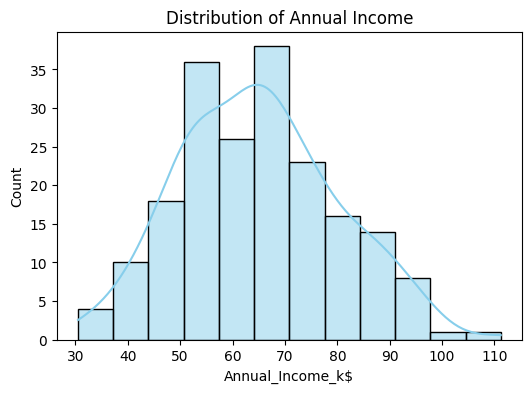

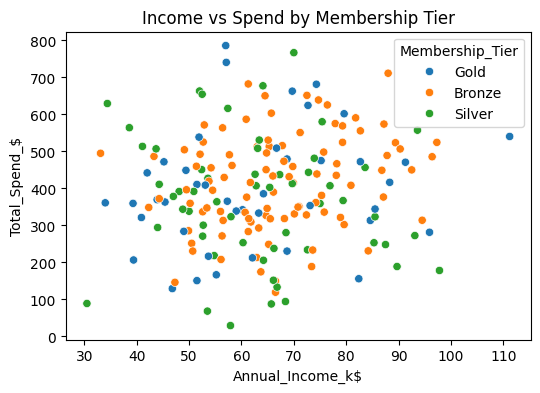

In [11]:
# Univariate: Plot the distribution of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df_clean['Annual_Income_k$'], kde=True, color='skyblue')
plt.title('Distribution of Annual Income')
plt.show()

# Bivariate: Relationship between Annual Income and Total Spend
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Annual_Income_k$', y='Total_Spend_$', hue='Membership_Tier')
plt.title('Income vs Spend by Membership Tier')
plt.show()

# Step 5: Feature Engineering
Transform features to make them machine-learning ready.

In [12]:
# 1. Binning: Categorize Age into life stages
bins = [0, 25, 45, 100]
labels = ['Young Adult', 'Middle Aged', 'Senior']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

# 2. Label Encoding: Convert ordinal Membership Tier to numbers
tier_mapping = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
df_clean['Membership_Tier_Encoded'] = df_clean['Membership_Tier'].map(tier_mapping)

# 3. One-Hot Encoding: Convert nominal Gender column
df_final = pd.get_dummies(df_clean, columns=['Gender'], drop_first=True)
print(df_final.head())

   Customer_ID   Age  Annual_Income_k$  Total_Spend_$ Membership_Tier  \
0         1001  28.0              84.6         313.48            Gold   
1         1002  35.0              65.3         513.31          Bronze   
2         1003  45.0              75.2         475.14            Gold   
3         1004  35.0              60.3         253.37          Silver   
4         1005  22.0              69.9         414.90          Bronze   

  Satisfied    Age_Group  Membership_Tier_Encoded  Gender_Male  
0        No  Middle Aged                        3        False  
1        No  Middle Aged                        1         True  
2        No  Middle Aged                        3         True  
3        No  Middle Aged                        2        False  
4       Yes  Young Adult                        1        False  


# 📝 Student Project Evaluation Criteria
To complete the project, students must bundle this code workflow into a final Jupyter Notebook submission containing code text blocks (Markdown) that answer:

What was the median age used to fill the missing gaps?

Why did we use One-Hot Encoding for the Gender column but Label Mapping for the Membership_Tier column?

Looking at the scatter plot, what trend do you notice regarding how different membership tiers spend money relative to their annual income?